<a href="https://colab.research.google.com/github/Chirag04-bit/GENERAL-HEALTH-PREDICTOR/blob/main/General_Health_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Imports
import sys, os, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from scipy.stats import randint, uniform, loguniform

# For saving models if desired
import joblib

RAND_SEED = 42
np.random.seed(RAND_SEED)

In [ ]:

# Load dataset
# In Colab, this cell will prompt for upload if the file is missing.
path_candidates = ["CVD_cleaned.csv", "/mnt/data/CVD_cleaned.csv"]
csv_path = None
for p in path_candidates:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    try:
        from google.colab import files
        uploaded = files.upload()  # Upload CVD_cleaned.csv
        csv_path = next(iter(uploaded.keys()))
    except Exception as e:
        raise FileNotFoundError("Please upload CVD_cleaned.csv or place it in the working directory.") from e

df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", df.shape)
display(df.head())


Loaded: CVD_cleaned.csv
Shape: (308854, 19)


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150,32.66,14.54,Yes,0,30,16,12
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165,77.11,28.29,No,0,30,0,4
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163,88.45,33.47,No,4,12,3,16
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180,93.44,28.73,No,0,30,30,8
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191,88.45,24.37,Yes,0,8,4,0


In [ ]:

# Heuristic to detect the target/label column.
# Preference order: 'General_Health'/'GeneralHealth'/'gen_health'/'HealthStatus'/'HeartDisease'/'target'/'label'
known_targets = ["General_Health", "GeneralHealth", "gen_health", "HealthStatus",
                 "HeartDisease", "target", "label", "Outcome"]
target_col = None
for k in known_targets:
    if k in df.columns:
        target_col = k
        break

# If not found, pick a column with small unique values (<=10) and not an ID-like column.
if target_col is None:
    candidates = []
    for c in df.columns:
        if df[c].nunique(dropna=True) <= 10 and not c.lower().endswith(("id","_id")) and c.lower() not in ["patientid", "id"]:
            candidates.append(c)
    if len(candidates) > 0:
        # choose the one with the fewest unique values (looks most like a class label)
        target_col = sorted(candidates, key=lambda x: df[x].nunique(dropna=True))[0]

if target_col is None:
    raise ValueError("Could not confidently detect a target column. Please rename your label column to 'General_Health' or set target_col manually.")

print("Detected target column:", target_col)

# Drop entirely empty columns
df = df.dropna(axis=1, how='all')

# Basic NA handling: drop rows where target is NA; impute features later via pipelines.
df = df.dropna(subset=[target_col])
df = df.reset_index(drop=True)

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Identify categorical vs numeric features
num_cols = X.select_dtypes(include=["int64","float64","int32","float32","int16","float16","bool"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))


Detected target column: General_Health
Numeric features: 7
Categorical features: 11


In [ ]:

# Preprocessing: OneHot for categorical, Standardize for numeric where needed
preprocessor_lr_svm = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), num_cols),  # with_mean=False handles sparse
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder='drop'
)

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder='drop'
)

# Define pipelines for each model
pipe_lr = Pipeline([("prep", preprocessor_lr_svm),
                    ("clf", LogisticRegression(max_iter=1000, n_jobs=None, random_state=RAND_SEED))])

pipe_svm = Pipeline([("prep", preprocessor_lr_svm),
                     ("clf", SVC(probability=True, random_state=RAND_SEED))])

pipe_rf = Pipeline([("prep", preprocessor_rf),
                    ("clf", RandomForestClassifier(random_state=RAND_SEED))])


In [ ]:
from sklearn.model_selection import train_test_split

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RAND_SEED, stratify=y if y.nunique() > 1 else None
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (247083, 18)  Test shape: (61771, 18)



=== Logistic Regression ===
Accuracy: 0.4254

Classification Report:
               precision    recall  f1-score   support

   Excellent       0.46      0.13      0.21     11191
        Fair       0.37      0.13      0.20      7162
        Good       0.41      0.43      0.42     19073
        Poor       0.42      0.06      0.10      2266
   Very Good       0.43      0.70      0.54     22079

    accuracy                           0.43     61771
   macro avg       0.42      0.29      0.29     61771
weighted avg       0.42      0.43      0.39     61771



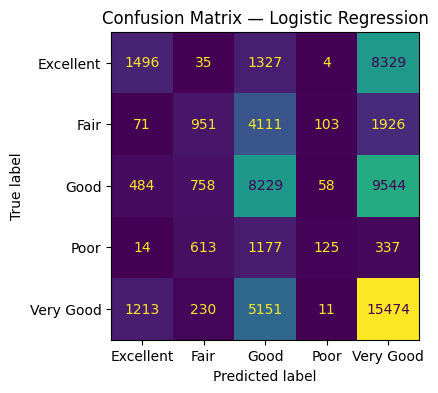


=== Linear SVM ===
Accuracy: 0.4175

Classification Report:
               precision    recall  f1-score   support

   Excellent       0.39      0.03      0.05     11191
        Fair       0.38      0.03      0.06      7162
        Good       0.40      0.42      0.41     19073
        Poor       0.00      0.00      0.00      2266
   Very Good       0.43      0.78      0.55     22079

    accuracy                           0.42     61771
   macro avg       0.32      0.25      0.21     61771
weighted avg       0.39      0.42      0.34     61771



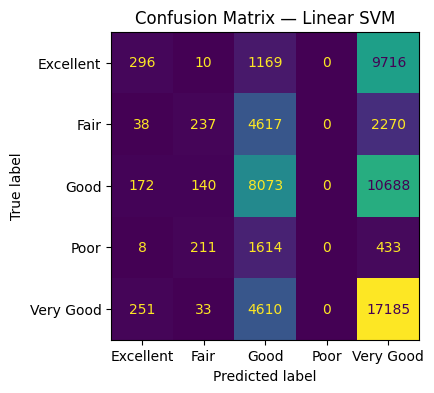


=== Random Forest ===
Accuracy: 0.4275

Classification Report:
               precision    recall  f1-score   support

   Excellent       0.50      0.12      0.20     11191
        Fair       0.37      0.15      0.21      7162
        Good       0.41      0.45      0.43     19073
        Poor       0.39      0.06      0.11      2266
   Very Good       0.44      0.69      0.54     22079

    accuracy                           0.43     61771
   macro avg       0.42      0.29      0.30     61771
weighted avg       0.43      0.43      0.39     61771



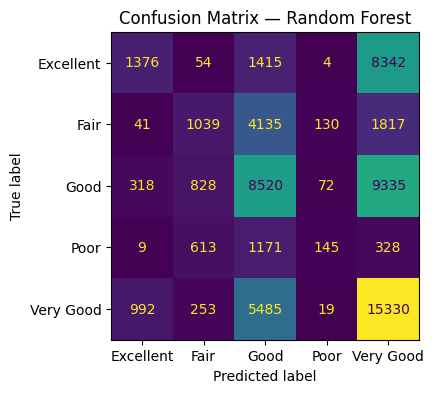

In [ ]:
from sklearn.svm import LinearSVC

# Faster pipelines
pipe_lr = Pipeline([
    ("prep", preprocessor_lr_svm),
    ("clf", LogisticRegression(max_iter=1000, n_jobs=-1, random_state=RAND_SEED))
])

pipe_svm = Pipeline([
    ("prep", preprocessor_lr_svm),
    ("clf", LinearSVC(random_state=RAND_SEED, max_iter=2000))   # much faster than SVC
])

pipe_rf = Pipeline([
    ("prep", preprocessor_rf),
    ("clf", RandomForestClassifier(
        n_estimators=50,      # reduced for speed
        max_depth=15,         # limit tree depth
        n_jobs=-1,            # parallelize
        random_state=RAND_SEED
    ))
])

models = {
    "Logistic Regression": pipe_lr,
    "Linear SVM": pipe_svm,
    "Random Forest": pipe_rf
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 4))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
    fig, ax = plt.subplots(figsize=(4,4))
    disp.plot(ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

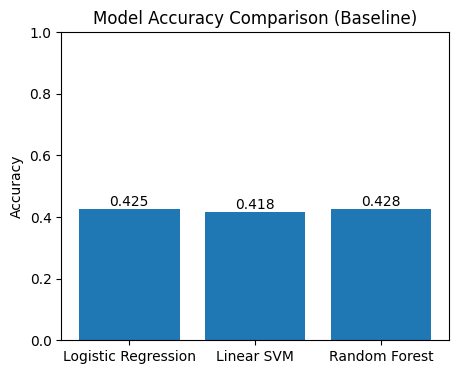

In [ ]:

# Accuracy comparison
names = list(accuracies.keys())
vals  = [accuracies[k] for k in names]

plt.figure(figsize=(5,4))
plt.bar(names, vals)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison (Baseline)")
for i, v in enumerate(vals):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.show()


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import loguniform, randint

# --- Randomized search spaces (optimized for speed) ---
param_distributions = {
    "Logistic Regression": {
        "clf__C": loguniform(1e-3, 1e2),
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs", "liblinear"],
    },
    "Linear SVM": {
        "clf__C": loguniform(1e-3, 1e2),
    },
    "Random Forest": {
        "clf__n_estimators": randint(50, 150),  # smaller range
        "clf__max_depth": randint(3, 15),
        "clf__min_samples_split": randint(2, 8),
        "clf__min_samples_leaf": randint(1, 4),
        "clf__max_features": ["sqrt", "log2"]
    }
}

tuned_models = {}
tuned_accuracies = {}

# --- Loop through models ---
for name, base_model in models.items():
    print(f"\n--- Randomized Search: {name} ---")
    rs = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions[name],
        n_iter=5,        # ultra-fast (only 5 parameter sets)
        cv=2,            # 2-fold CV
        scoring="accuracy",
        random_state=RAND_SEED,
        n_jobs=-1,
        verbose=1
    )

    # Fit search
    rs.fit(X_train, y_train)

    # Store best model
    tuned_models[name] = rs.best_estimator_

    # Report
    print("Best Params:", rs.best_params_)
    y_pred = rs.best_estimator_.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    tuned_accuracies[name] = acc
    print("Tuned Test Accuracy:", round(acc, 4))
    print("\nTuned Classification Report:\n", classification_report(y_test, y_pred))




--- Randomized Search: Logistic Regression ---
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Params: {'clf__C': np.float64(0.9846738873614566), 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Tuned Test Accuracy: 0.4256

Tuned Classification Report:
               precision    recall  f1-score   support

   Excellent       0.46      0.13      0.21     11191
        Fair       0.37      0.13      0.20      7162
        Good       0.41      0.43      0.42     19073
        Poor       0.42      0.06      0.10      2266
   Very Good       0.43      0.70      0.54     22079

    accuracy                           0.43     61771
   macro avg       0.42      0.29      0.29     61771
weighted avg       0.42      0.43      0.39     61771


--- Randomized Search: Linear SVM ---
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Params: {'clf__C': np.float64(0.0745934328572655)}
Tuned Test Accuracy: 0.4176

Tuned Classification Report:
               precision    r

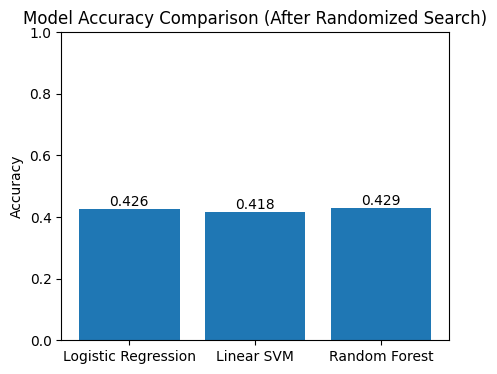

In [ ]:

# Tuned accuracy comparison
names_t = list(tuned_accuracies.keys())
vals_t  = [tuned_accuracies[k] for k in names_t]

plt.figure(figsize=(5,4))
plt.bar(names_t, vals_t)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison (After Randomized Search)")
for i, v in enumerate(vals_t):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.show()


In [ ]:

# Single-input prediction using the best tuned model
# We will pick the best performer among tuned models
best_name = max(tuned_accuracies, key=tuned_accuracies.get)
best_model = tuned_models[best_name]

print("Best model after tuning:", best_name, "with accuracy:", round(tuned_accuracies[best_name], 4))

# Take one sample from X_test to simulate AI system working
sample = X_test.iloc[[0]]  # keep DataFrame shape
pred = best_model.predict(sample)[0]

print("\n--- Single Input Prediction Demo ---")
print("Input features (first row of X_test):")
display(sample)
print("Predicted Health Status:", pred)

# Optionally save the best model
joblib.dump(best_model, f"best_model_{best_name.replace(' ','_').lower()}.joblib")
print("Saved model file:", f"best_model_{best_name.replace(' ','_').lower()}.joblib")


Best model after tuning: Random Forest with accuracy: 0.429

--- Single Input Prediction Demo ---
Input features (first row of X_test):


,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
28559,Within the past year,Yes,No,No,No,No,Yes,No,Female,45-49,165,98.43,36.11,Yes,0,30,30,4


Predicted Health Status: Good
Saved model file: best_model_random_forest.joblib
